In [1]:
## BC Diagnosis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set(style="white", color_codes=True)

from sklearnex import patch_sklearn
patch_sklearn()

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import sklearn
from sklearn.datasets import load_breast_cancer
%matplotlib inline
import sklearn.model_selection

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [3]:
# DataSet

# ds = load_breast_cancer(as_frame=True);
ds = load_breast_cancer();
ds

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [4]:
ds.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
ds.target_names

array(['malignant', 'benign'], dtype='<U9')

In [6]:
ds.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [7]:
# DataFrame

# df = pd.DataFrame(data=ds.data)
df = pd.DataFrame(data=ds.data, columns=ds.feature_names)
df["target"] = ds.target
# df["target_name"] = ds.target_names

# df['target'] = pd.Series(ds.target, name='target_values')
# df['target_name'] = df['target'].replace([0,1,2], ['iris-' + species for species in ds.target_names.tolist()])
# df["target_name"] = ds.target_names

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# df.columns = ds.feature_names
# df.head()

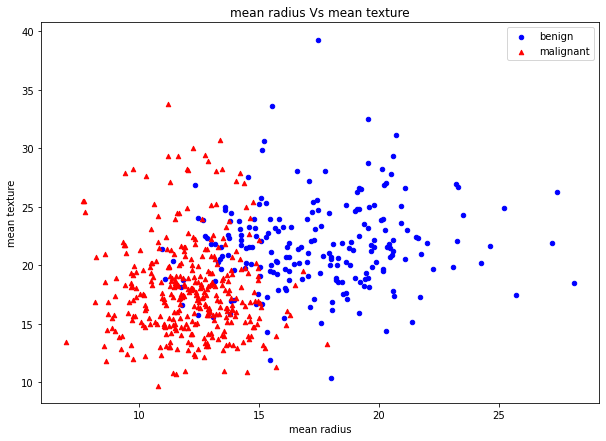

In [8]:
# Graph 1 (matplotlib.pyplot). "Sepal Width" vs "Sepal Length"
# Conclusion of this graph: "Sepal Width" vs "Sepal Length" is NOT significant for "Versicolor and Virginica"

ax = plt.axes()
df[df.target == 0].plot(kind='scatter', x='mean radius', y='mean texture', color='blue', marker="o", label='benign', ax=ax)
df[df.target == 1].plot(kind='scatter', x='mean radius', y='mean texture', color='red', marker="^", label='malignant', ax=ax)

ax.set_xlabel('mean radius')
ax.set_ylabel('mean texture')
ax.set_title('mean radius Vs mean texture')

fig=plt.gcf()
fig.set_size_inches(10, 7)
plt.show()

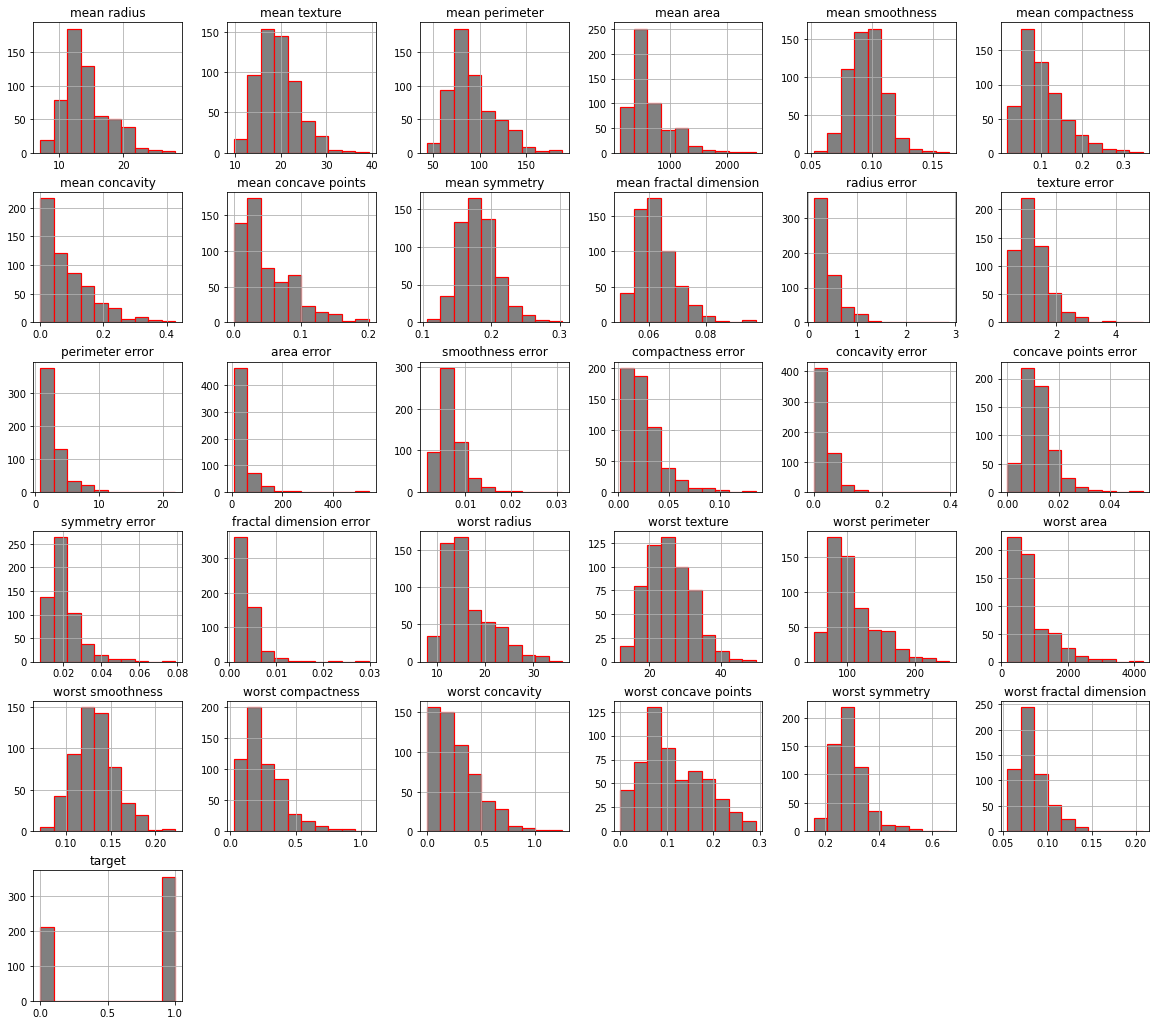

In [9]:
# Graph 5 (matplotlib.pyplot histogram).
# Conclusion of histograms: NOT significance found

df.hist(color='grey', edgecolor='red', linewidth=1.2)
fig = plt.gcf()
fig.set_size_inches(20, 18)
plt.show()

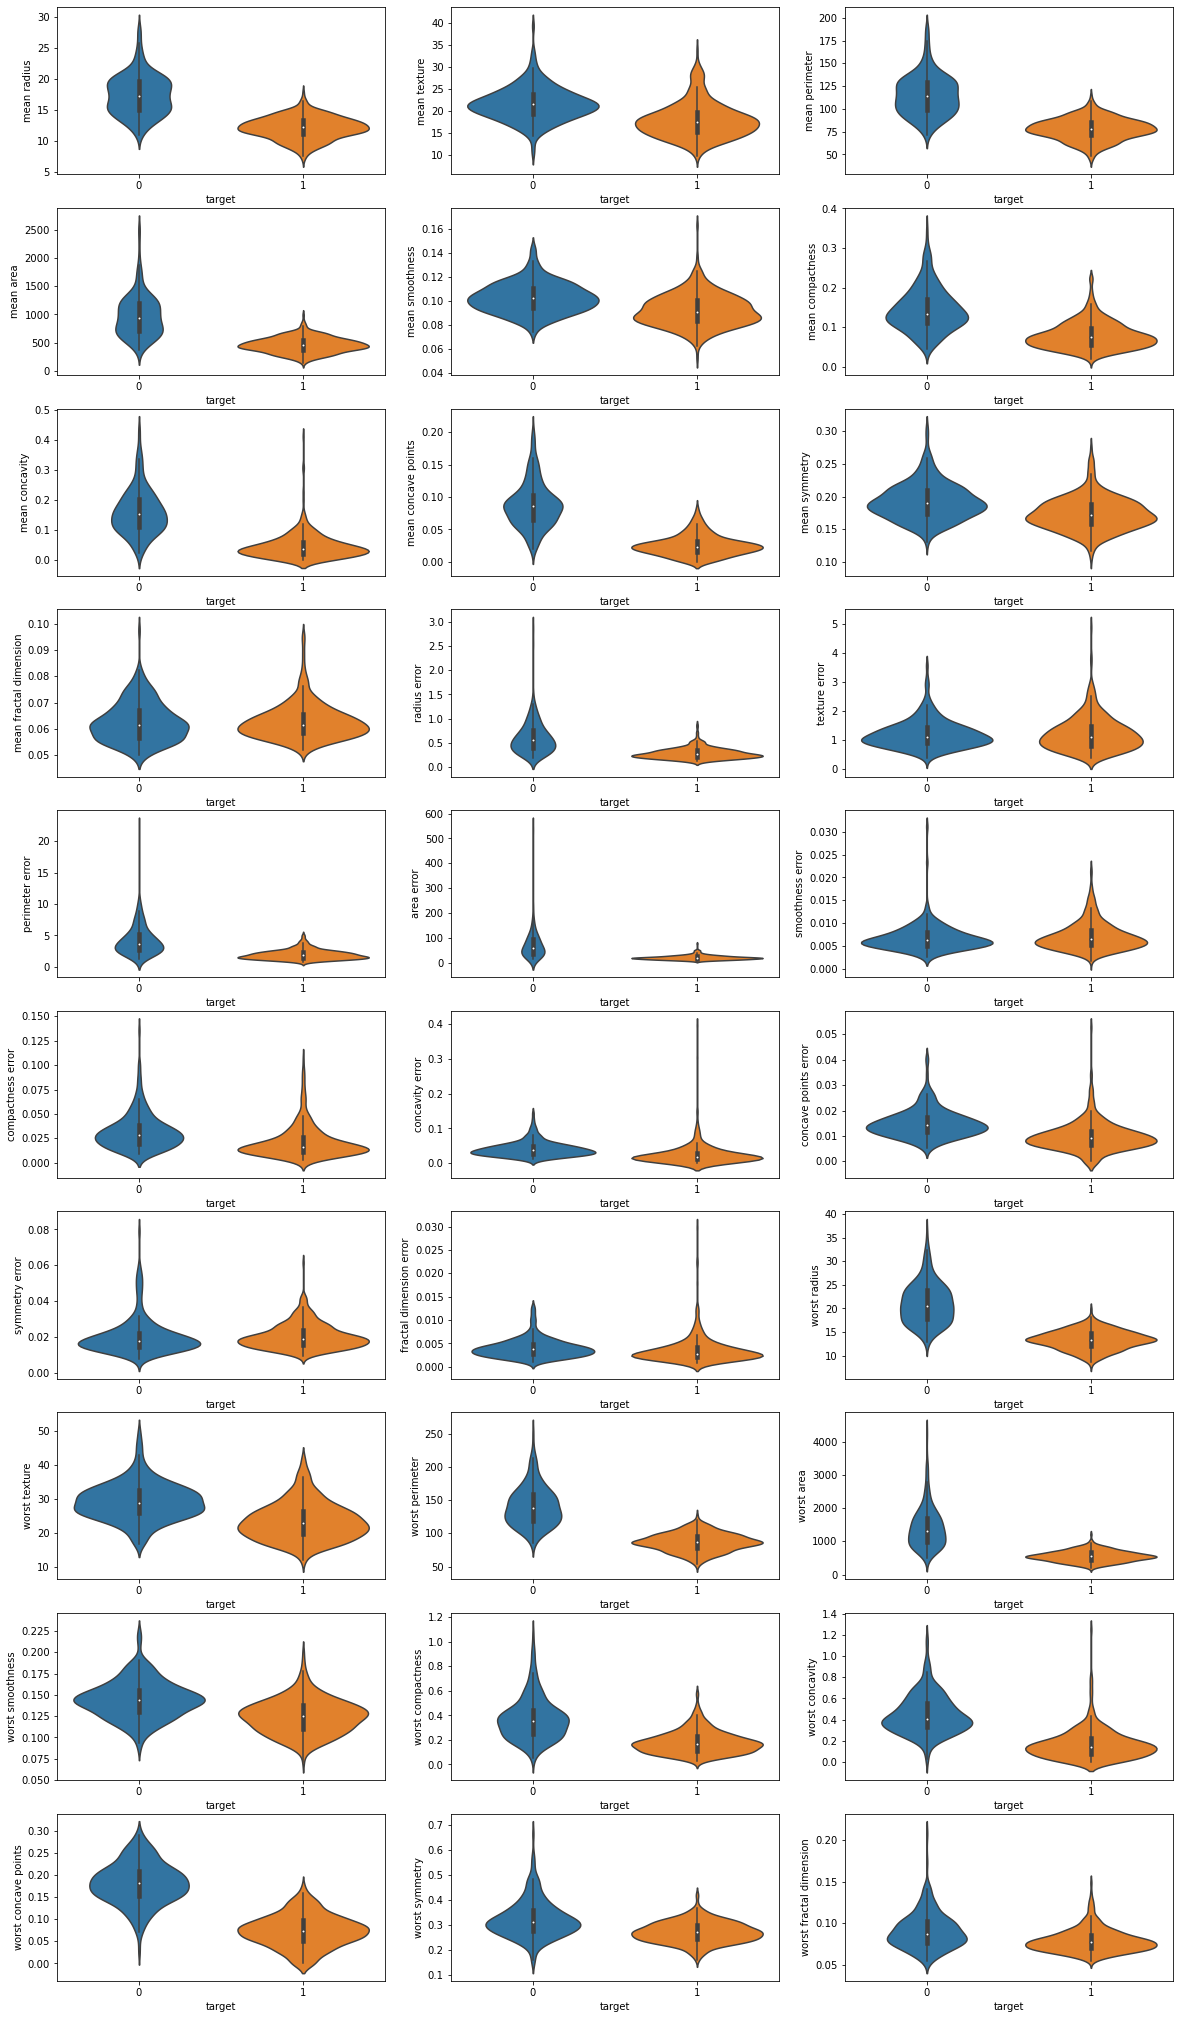

In [10]:
# Graph 7 (seaborn.violinplot).
# Conclusion of histograms: (1) Petal Length and Species are related. (2) Petal Width and Species are related.

from math import ceil

ncols = 3
nrows = ceil(len(df.columns) / ncols)

idx = 0
for i, col in enumerate(df.columns):
    if col == 'target':
        continue
    idx += 1
    plt.subplot(nrows, ncols, idx)
    sns.violinplot(x='target', y = col, data=df)

fig = plt.gcf()
fig.set_size_inches(20, 40)

plt.show()

In [11]:
# df.info()

In [12]:
X=ds.data
y=ds.target
# print(X)
# print(y)

In [13]:
# Split train and test data

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.25, random_state=20)

In [14]:
# 1. Train LogisticRegression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=0, solver="lbfgs", max_iter=5000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('The accuracy of the LogisticRegression is: ', accuracy_score(y_pred, y_test))

[[53  4]
 [ 3 83]]
The accuracy of the LogisticRegression is:  0.951048951048951


In [15]:
# 2. Train KNearestNeighbor

from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('The accuracy of the KNearestNeighbor is: ', accuracy_score(y_pred, y_test))

[[51  6]
 [ 4 82]]
The accuracy of the KNearestNeighbor is:  0.9300699300699301


In [16]:
# 3. Train SVC using Support Vector Machines Algorithm

from sklearn.svm import SVC

model = SVC(kernel = 'linear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('The accuracy of the SVC using Support Vector Machines Algorithm is: ', accuracy_score(y_pred, y_test))

[[53  4]
 [ 2 84]]
The accuracy of the SVC using Support Vector Machines Algorithm is:  0.958041958041958


In [17]:
# 4. Train SVC using Kernel SVM Algorithm

from sklearn.svm import SVC

model = SVC(kernel = 'rbf')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('The accuracy of the SVC using Kernel SVM Algorithm is: ', accuracy_score(y_pred, y_test))

[[48  9]
 [ 2 84]]
The accuracy of the SVC using Kernel SVM Algorithm is:  0.9230769230769231


In [18]:
# 5. Train GaussianNB using Naive Bayes Algorithm

from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('The accuracy of the GaussianNB using Naive Bayes Algorithm is: ', accuracy_score(y_pred, y_test))

[[52  5]
 [ 2 84]]
The accuracy of the GaussianNB using Naive Bayes Algorithm is:  0.951048951048951


In [19]:
# 6. Train DecisionTree

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion = 'entropy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('The accuracy of the DecisionTree is: ', accuracy_score(y_pred, y_test))

[[54  3]
 [ 4 82]]
The accuracy of the DecisionTree is:  0.951048951048951


In [20]:
# 7. Train RandomForest

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 10, criterion = 'entropy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('The accuracy of the RandomForest is: ', accuracy_score(y_pred, y_test))

[[55  2]
 [ 6 80]]
The accuracy of the RandomForest is:  0.9440559440559441
